In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [6]:
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df.drop("CustomerID",axis=1,inplace=True)

In [7]:
X=df.columns
x_train, x_test = train_test_split(df, test_size=0.2, random_state=42)
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)  

In [8]:
wcss=[]
for i in range(1,11):
    
    kmeans=KMeans(n_clusters=i,random_state=42,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)
    
    
    

In [9]:
wcss

[70.10782278872972,
 30.807128964660045,
 25.148446760435018,
 18.986931003389362,
 17.29588609307089,
 14.782081991280187,
 12.369377734464237,
 10.77584279712277,
 9.580112667393543,
 8.94481309978311]

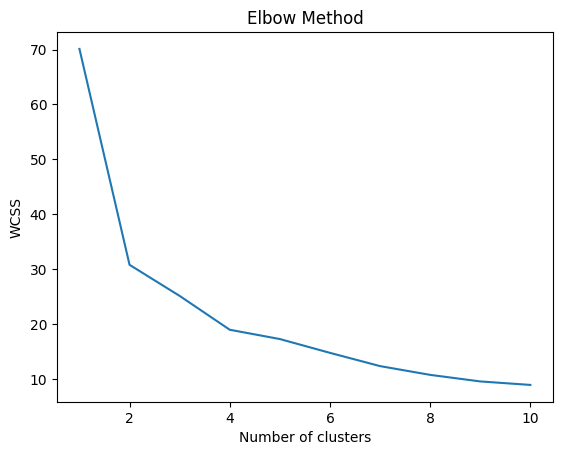

In [10]:
plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans=KMeans(n_clusters=2,random_state=42)
kmeans.fit(x_train)
y_kmeans=kmeans.predict(x_test)
y_kmeans

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

In [12]:
silhouette_score(x_test,y_kmeans)

np.float64(0.5444886406138608)

TypeError: 'dict' object is not callable